In [1]:
import numpy as np
import pandas as pd
import os, os.path
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import scipy.stats
import pickle
from statsmodels.distributions.empirical_distribution import ECDF
import pybobyqa
from tqdm import tqdm


# Optimization

In [2]:

def upload_static_shared(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper,ETA):
    cap_static = np.load(os.path.join(ROOT_DIR,f'{save_folder}/{city}/PHI_{phi}/ETA_{ETA}/Th_{delay}/cap_fore_uncer_test_block1_delay_{delay}_phi_{phi}_gamma_2_deltax_005.npy'))
    cap_shared=np.load(os.path.join(ROOT_DIR,f'{save_folder}/{city}/PHI_{phi}/ETA_{ETA}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/shared_fore_uncer_block2_delay_{delay}_phi_{phi}_alpha_{alpha}_gamma_2.npy'))
    #cap_shared = np.load(f'Results/{city}/Th_{delay}/shared_fore_uncer_block2_delay_{delay}_phi_{phi}_alpha_{alpha}_gamma_2.npy')

    dist_cd = scipy.stats.norm(loc=cap_static.mean(axis=-1),
                               scale=cap_static.std(axis=-1))
    dist_cs = scipy.stats.norm(loc=cap_shared.mean(axis=-1),
                               scale=cap_shared.std(axis=-1))
    
    ppf_static = 0.999
    ppf_helper = 0.999

    ### Maybe this ppf values does not have to be the same as the one used in the forecast ???
    upper_cd_static = dist_cd.ppf(ppf_static) # Can be changed. If set to 0.5 = mean
    upper_cd_static[np.where(np.isnan(upper_cd_static))] = (
        cap_static[np.where(np.isnan(upper_cd_static))][:, 0])
    upper_cs_shared = dist_cs.ppf(ppf_helper) # Can be changed. If set to 0.5 = mean 
    upper_cs_shared[np.where(np.isnan(upper_cs_shared))] = (
        cap_shared[np.where(np.isnan(upper_cs_shared))][:, 0])

    return upper_cd_static, upper_cs_shared

def cost_func_evaluation(c_plus, forecasting, static, phi, alpha):
    ''' Evaluate the cost of the allocation given cplus selected.'''
    # cost_shared = phi
    cost_sla = alpha
    total_cost = 0
    for i in range(forecasting.shape[0]):  # shape[0] = num services
        # total_cost += cost_shared * c_plus[i]
        ecdf = ECDF(forecasting[i])
        total_cost += (1-ecdf(static[i] + c_plus[i])) * cost_sla
    return total_cost

def apps_need_shared(forecasting, static):
    ''' Return the slices that need shared capacity '''
    index_app = []
    for app in range(forecasting.shape[0]):
        dist = ECDF(forecasting[app])
        if (1 - dist(static[app])) != 0:
            index_app.append(app)
    return index_app


def fun(pn, dist, static, max_shared, phi, alpha, lower_bound, upper_bound,obj_noise_test): # Golden search
    """ Function with only one variable to be minimized through
        bounded golden search
    """
    num_app = dist.shape[0]
    p_0 = np.ones(num_app) * 0.5
    opt = pybobyqa.solve(cost_func_evaluation_p_fix_p4, p_0,
                         bounds=(lower_bound[:num_app], upper_bound[:num_app]),
                         args=(dist, static, max_shared, pn, phi, alpha),
                         objfun_has_noise=obj_noise_test)
    return opt.f


def cost_func_evaluation_p(p, forecasting, static, shared_available, phi,
                           alpha):
    ''' Evaluate the cost of the allocation given cplus selected.'''
    # cost_shared = phi
    cost_sla = alpha
    total_cost = 0
    cplus = return_cplus(p, shared_available)
    for i in range(forecasting.shape[0]):  # shape[0] = num services
        # total_cost += cost_shared * cplus[i]
        ecdf = ECDF(forecasting[i])
        total_cost += (1-ecdf(static[i] + cplus[i])) * cost_sla
    return total_cost


def cost_func_evaluation_p_fix_p4(p, forecasting, static, shared_available, p4,
                                  phi, alpha):
    ''' Evaluate the cost of the allocation given cplus selected.'''
    # cost_shared = phi
    cost_sla = alpha
    total_cost = 0
    cplus, cplus_4 = return_cplus_fix_p4(p, shared_available, p4)
    for i in range(forecasting.shape[0]):  # shape[0] = num services
        # total_cost += cplus[i] * phi
        ecdf = ECDF(forecasting[i])
        total_cost += (1-ecdf(static[i] + cplus[i])) * cost_sla
    return total_cost


def return_cplus(p_vector, shared_available): # Transform function from the paper
    """ Return c_plus given p and max amount of shared for
    that phi,alpha and time.
    """
    cplus = np.zeros(p_vector.shape)
    products = np.zeros(p_vector.shape[0]-1)
    for i in range(len(cplus)-1):
        products[i] = np.true_divide(np.prod(p_vector[i:-1]),
                                     np.prod((1-p_vector)[i:-1]))
    cplus[-1] = np.true_divide(shared_available * p_vector[-1],
                               np.sum(products) + 1)
    for i in range(len(cplus)-1):
        cplus[i] = products[i] * cplus[-1]
    return cplus


def return_cplus_fix_p4(p_vector, shared_available, p4): # Transform function from the paper
    """ Return c_plus given p and max amount of shared for
    that phi,alpha and time. """
    cplus = np.zeros(p_vector.shape)
    products = np.zeros(p_vector.shape[0])
    for i in range(len(cplus)):
        products[i] = np.true_divide(np.prod(p_vector[i:]),
                                     np.prod((1-p_vector)[i:]))
    cplus4 = np.true_divide(shared_available * p4,
                            np.sum(products) + 1)
    # for i in range(len(cplus)):
    #     cplus[i] = products[i] * cplus4
    cplus = products * cplus4
    return cplus, cplus4


def return_p(cplus, max_shared):
    p = np.zeros(cplus.shape)
    for i in range(cplus.shape[0] - 1):
        p[i] = cplus[i] / (cplus[i]+cplus[i+1])
    p[-1] = np.sum(cplus) / max_shared
    return p



def load_real_data(city):
    ''' Load the real data for the city.'''

    bordeaux = pd.read_csv(os.path.join(ROOT_DIR,f'./citys/{city}.csv'))
    #bordeaux = pd.read_csv(f'/home/sergi_alcala/AZTEC_extension/citys/{city}.csv')

    bordeaux.drop('date_time', axis=1, inplace=True)
    bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
    bordeaux = bordeaux.to_numpy()
    return bordeaux

def load_mae_forecasting(city):
    mae_forecasting = np.transpose(np.load(os.path.join(ROOT_DIR,f'./{save_folder}/{city}/helper_forecasting_delay_1.npy')), (0,2,1))
    return mae_forecasting

def load_scalers(city, ppf_static, ppf_helper,delay,ETA):
    static_scaler = pickle.load(open(os.path.join(ROOT_DIR,f'{save_folder}/{city}/PHI_{phi}/ETA_{ETA}/Th_{delay}/block_1_minmaxscaler.pkl'), 'rb'))
    shared_scaler = pickle.load(open(os.path.join(ROOT_DIR,f'{save_folder}/{city}/PHI_{phi}/ETA_{ETA}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/block_2_minmaxscaler.pkl'), 'rb'))
    return static_scaler, shared_scaler

def denormalize_normalize_static_shared(static,shared, static_scaler,shared_scaler, mae_forecasting, real_data, test_index_start):
    ''' Denormalize the static data using the scaler. '''
    static_denorm = static_scaler.inverse_transform(static) # Static = block 1
    shared_denorm = shared_scaler.inverse_transform(np.expand_dims(shared, axis=-1)) # Shared = block 2
    mae_denorm = np.zeros(mae_forecasting.shape) # MAE = helper
    for i in range(B):
        mae_denorm[:,:,i] = static_scaler.inverse_transform(mae_forecasting[:,:,i])
    ''' Normalize the data to be in the same scale as the real data.'''
    shared_norm = shared_denorm / 10e9 # Shared = block 2
    static_norm = static_denorm / 10e9 # Static = block 1
    mae_norm = mae_denorm / 10e9 # MAE = helper
    output_norm = real_data[test_index_start:] / 10e9 # Real test data
    diff = min(mae_norm.shape[0], output_norm.shape[0], shared_norm.shape[0], static_norm.shape[0])

    mae_norm_diff = mae_norm.shape[0] - diff
    output_norm_diff = output_norm.shape[0] - diff
    shared_norm_diff = shared_norm.shape[0] - diff
    static_norm_diff = static_norm.shape[0] - diff

    if mae_norm_diff != 0:
        mae_norm = mae_norm[mae_norm_diff:]
    if output_norm_diff != 0:
        output_norm = output_norm[output_norm_diff:]
    if shared_norm_diff != 0:
        shared_norm = shared_norm[shared_norm_diff:]
    if static_norm_diff != 0:
        static_norm = static_norm[static_norm_diff:]

    return static_norm, shared_norm, mae_norm, output_norm

def create_df_shared_cplus_sla(slas, cplus, shared_needed,num_services,Filesave,delay,phi,alpha):
    
    shared_needed_df=pd.DataFrame(shared_needed)
    cplus_df=pd.DataFrame(cplus)
    slas_df=pd.DataFrame(slas)
    shared_cplus_sla=pd.concat([shared_needed_df, cplus_df, slas_df], axis=0)
    shared_needed_idx=[f'shared_needed_{i}' for i in range(num_services)]
    cplus_idx=[f'cplus_{i}' for i in range(num_services)]
    slas_idx=[f'slas_{i}' for i in range(num_services)]
    shared_cplus_sla.index=shared_needed_idx+cplus_idx+slas_idx
    shared_cplus_sla=shared_cplus_sla.T
    shared_needed_df=shared_needed_df.T
    cplus_df=cplus_df.T
    slas_df=slas_df.T
    shared_cplus_sla.to_csv(f'{Filesave}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_2.csv',index=False)
    shared_needed_df.to_csv(f'{Filesave}/Block_3_shared_needed_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_2.csv',index=False)
    cplus_df.to_csv(f'{Filesave}/Block_3_cplus_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_2.csv',index=False)
    slas_df.to_csv(f'{Filesave}/Block_3_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_2.csv',index=False)


def allocation_loop(static_norm, shared_norm, mae_norm, output_norm, num_services,  phi, alpha,delay, Filesave):

    length_tsteps = min(len(shared_norm),len(output_norm))
    slas = np.zeros((num_services, length_tsteps)) # number of slas for each time step
    cplus = np.zeros((num_services, length_tsteps)) # shared allocated to each app for each time step
    shared_needed=np.zeros((num_services, length_tsteps)) # shared needed for each app for each time step ### Sergi ###
    p = np.zeros((num_services, length_tsteps)) 
    lower_bound = np.ones(num_services) * 1e-10
    upper_bound = np.ones(num_services) * 0.99999
    idx_time = 1
    try:
        for time in tqdm(range(0, length_tsteps)):
            forecasting = mae_norm[time] # forecasting.shape = (5, 100)
            idx_app = apps_need_shared(forecasting, static_norm[time])
            if len(idx_app) > 1:
            ##Try catch used because the assymetry  of the matrix, solved by changing the parameter objfun_has_noise True or False
            
                try:
                    obj_noise_test = True
                # Golden search for setting p4
                    test = scipy.optimize.minimize_scalar(fun, bounds=(1e-10, 0.99999), method='bounded',
                                                        args=(forecasting[idx_app[:-1]], static_norm[time, idx_app[:-1]],
                                                                shared_norm[time], phi, alpha, lower_bound, upper_bound,obj_noise_test))
                except:
                    print (f'obj_noise_test = False for time {time}')
                    obj_noise_test = False
                    test = scipy.optimize.minimize_scalar(fun, bounds=(1e-10, 0.99999), method='bounded',
                                                        args=(forecasting[idx_app[:-1]], static_norm[time, idx_app[:-1]],
                                                                shared_norm[time], phi, alpha, lower_bound, upper_bound,obj_noise_test))
                p4 = test.x # p4 obtained using golden search
                p_0 = np.ones(len(idx_app)-1) * 0.5 # initial values of p from 0 to 3
            # Finding the best initial values of p from 0 to 3 keeping p4 fixed. BOBYQA for p from 0 to 3.
                try:
                    
                    prova = pybobyqa.solve(cost_func_evaluation_p_fix_p4, p_0, bounds=(lower_bound[:len(idx_app)-1],
                                                                                    upper_bound[:len(idx_app)-1]),
                                        args=(forecasting[idx_app[:-1]], static_norm[time, idx_app[:-1]],
                                                shared_norm[time], p4, phi, alpha), objfun_has_noise=True)
                    #print('objfun_has_noise=True for prova')
                except:
                    print (f'objfun_has_noise=False for time {time} in prova')
                    prova = pybobyqa.solve(cost_func_evaluation_p_fix_p4, p_0, bounds=(lower_bound[:len(idx_app)-1],
                                                                                upper_bound[:len(idx_app)-1]),
                                    args=(forecasting[idx_app[:-1]], static_norm[time, idx_app[:-1]],
                                            shared_norm[time], p4, phi, alpha), objfun_has_noise=False)
                    #print('objfun_has_noise=False for prova')
                p_0 = np.zeros(len(idx_app))
                p_0[:len(idx_app)-1] = prova.x
                p_0[-1] = p4
            # Now we have the "best" initial values for p, so we run the allocation algorithm for all p. BOBYQA for all p.
                try:
                    
                    prova_2 = pybobyqa.solve(cost_func_evaluation_p, p_0, bounds=(lower_bound[:len(idx_app)],
                                                                                upper_bound[:len(idx_app)]),
                                            args=(forecasting[idx_app], static_norm[time, idx_app],
                                                shared_norm[time], phi, alpha), objfun_has_noise=True)
                    #print('objfun_has_noise=True for prova_2')
                except:
                    # print (f'objfun_has_noise=False for time {time} in prova_2')
                    prova_2 = pybobyqa.solve(cost_func_evaluation_p, p_0, bounds=(lower_bound[:len(idx_app)],
                                                                            upper_bound[:len(idx_app)]),
                                        args=(forecasting[idx_app], static_norm[time, idx_app],
                                            shared_norm[time], phi, alpha), objfun_has_noise=False)
                #print('objfun_has_noise=False for prova_2')
                cplus[idx_app, time] = return_cplus(prova_2.x, shared_norm[time]) # cplus = shared capacity allocated to each service.
                p[idx_app, time] = prova_2.x
            elif len(idx_app) == 1:
            # In case we have only one application requesting shared capacity, I assign all the shared available to it.
                cplus[idx_app, time] = shared_norm[time]
            shared_needed[:, time] = output_norm[time] - static_norm[time] # It gives you the total shared required at that time.
            for app in range(num_services):
                if shared_needed[app, time] > cplus[app, time]:
                    slas[app, time] += 1
            #print(f'\rTime={time}, {idx_app}, Shared needed: {shared_needed[:,time]}, slas: {slas[:, time]}, cplus: {cplus[:, time]}', end='')
        create_df_shared_cplus_sla(slas, cplus, shared_needed,num_services,Filesave,delay,phi,alpha) ### Sergi ###
    except:
        with open ('/home/sergi_alcala/sergi_data/AZTEC_extension/Results/Error.txt', 'a') as f:
            error_txt=f'Error in city {city}, phi {phi}, alpha {alpha}, ppf_static {ppf_static}, ppf_helper {ppf_helper}, delay {delay}, ETA {ETA}'
            print(error_txt)
            f.write(error_txt+'\n')
           
       
        pass

def fun_test_index_start(city,delay):
    bordeaux= load_real_data(city)
    test_index_start = round(len(bordeaux)*0.8) + delay
    return test_index_start





# Plotting

In [3]:

# ROOT_DIR = os.path.realpath(os.path.join(os.path.dirname(__file__), '.'))
ROOT_DIR='/home/sergi_alcala/sergi_data/AZTEC_extension'
print(f'Root dir: {ROOT_DIR}')

lookback = 6
num_services = 5

B = 100
# test_index_start = 2016*8 + delay   # First sample start at test + 6.

def fun_test_index_start(city,delay):
    bordeaux= load_real_data(city)
    test_index_start = round(len(bordeaux)*0.8) + delay
    return test_index_start





LOOKBACK = 6 # History given as input to the network. Could be modified if needed

GAMMA = 2 # Positive slope of the loss function
NUM_SERV_B1 = 5 # number of services for the block 1
NUM_SERV_H = 1 # number of services for the helper

#B = 100 # Number of montecarlo output
B=100
#ppf_helper = 0.75 # Percentile of the helper
#ppf_static = 0.1 # Percentile of the static model


# ppf_helper_list=[0.5,0.65,0.70,0.75,0.9,0.95,0.99]
# ppf_helper_list=[0.99]
ppf_helper_list=[0.7]
# ppf_static_list=[0.2,0.3,0.5,0.75,0.9]
ppf_static_list=[0.9]

SEL_SERVS=[0, 1, 2, 3, 4] #Services to be selected for Helper Block
# PHIS = [10,1,0.1] # Negative slope of the loss function TO BE MODIFIED 
PHIS=[0.1]
# cities = ['Bordeaux','Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
#         'Nice', 'Paris', 'Reims', 'Rennes', 'Strasbourg', 'Toulouse']
# cities = ['Bordeaux','Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
        # 'Nice', 'Paris', 'Reims', 'Rennes']
cities = ['Paris']
# ETAS =[1,2,10,20,30,40,50,70,90,100]
ETAS = [1]
#Error in city Toulouse, phi 10, alpha 3, delay 6, ppf_static 0.9, ppf_helper 0.99

#save_folder = 'Results_Pipeline'   
# save_folder = 'Test_lengths'

save_folder = 'Results_Optimal_Cities_test_kr_ki_ALLOC_changed'

# ALPHAS=[0.75,2,3,5]
# ALPHAS=[2,3,5]
ALPHAS = [2]

# real_data, mae_forecasting=load_real_data(city), load_mae_forecasting(city)
# static_scaler, shared_scaler = load_scalers(city, ppf_static, ppf_helper)
# static,shared=upload_static_shared(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper)
# static_norm, shared_norm, mae_norm, output_norm = denormalize_normalize_static_shared(static, shared, static_scaler, shared_scaler, mae_forecasting, real_data, test_index_start)
# allocation_loop(static_norm, shared_norm, mae_norm, output_norm, num_services,  phi, alpha)



Root dir: /home/sergi_alcala/sergi_data/AZTEC_extension


In [4]:

for city in tqdm(cities):
    for ppf_helper in tqdm(ppf_helper_list):
        for ppf_static in tqdm(ppf_static_list):
            for phi in tqdm(PHIS):  
                for alpha in tqdm(ALPHAS):
                    for eta in tqdm(ETAS) :
                        delay=np.load(f'{ROOT_DIR}/{save_folder}/{city}/PHI_{phi}/ETA_{eta}/overall_optimal_window.npy')
                        # delay=5
                        Filesave=f'{save_folder}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}'
                        test_index_start=fun_test_index_start(city,delay)
                        print(f'City: {city}, ppf_static: {ppf_static}, ppf_helper: {ppf_helper}, phi: {phi}, alpha: {alpha}, delay: {delay}')
                   
                        real_data, mae_forecasting=load_real_data(city),load_mae_forecasting(city)
                        static_scaler, shared_scaler = load_scalers(city, ppf_static, ppf_helper,delay,eta)
                        static,shared=upload_static_shared(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper,eta)
                        # print(ETA)
                        static_norm, shared_norm, mae_norm, output_norm = denormalize_normalize_static_shared(static, shared, static_scaler, shared_scaler, mae_forecasting, real_data, test_index_start)
                        cplus = pd.read_csv(f'{ROOT_DIR}/{save_folder}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_cplus_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_2.csv')
                        # allocation_loop(static_norm, shared_norm, mae_norm, output_norm, num_services,  phi, alpha,delay,Filesave)



  0%|          | 0/1 [00:00<?, ?it/s]











City: Paris, ppf_static: 0.9, ppf_helper: 0.7, phi: 0.1, alpha: 2, delay: 21


/home/sergi_alcala/anaconda3/envs/AZTEC_ext/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:2244: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/sergi_alcala/anaconda3/envs/AZTEC_ext/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:2245: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc




100%|██████████| 1/1 [00:00<00:00,  2.28it/s]



100%|██████████| 1/1 [00:00<00:00,  2.25it/s]


100%|██████████| 1/1 [00:00<00:00,  2.23it/s]

100%|██████████| 1/1 [00:00<00:00,  2.16it/s]


In [7]:
cplus[150:175]

,0,1,2,3,4
150,0.000000,0.584871,0.504168,0.434471,0.000000
151,0.000000,0.053851,0.238878,0.363164,0.867616
152,0.053069,0.338273,0.648459,0.061827,0.213463
153,0.108045,0.465615,0.483848,0.172112,0.000000
154,0.097272,0.207070,0.634427,0.370079,0.069730
155,0.095473,0.190468,0.769034,0.366222,0.102312
156,0.206014,0.233891,0.613360,0.339581,0.130665
157,0.188216,0.305478,0.727972,0.219964,0.081879
158,0.248533,0.291652,0.067034,0.505856,0.410434
159,2.833367,0.000000,2.442409,2.104762,0.000000


In [15]:
static_norm.shape

(3561, 5)

In [20]:
output_norm.shape

(3561, 5)

In [17]:
static_cplus = static_norm + cplus_np

In [ ]:
# output_norm[150:175] > static_cplus[150:175]

In [69]:
#find the index where output is greater than static + cplus
idx = np.where(output_norm < static_norm)



In [77]:
aaa = pd.DataFrame(idx).T

In [85]:
aaa.iloc[500,:]

0    134
1      0
Name: 500, dtype: int64

In [72]:
aaa

[   0    0    0 ... 3560 3560 3560]


In [64]:
cplus[150:180]

,0,1,2,3,4
150,0.000000,0.584871,0.504168,0.434471,0.000000
151,0.000000,0.053851,0.238878,0.363164,0.867616
152,0.053069,0.338273,0.648459,0.061827,0.213463
153,0.108045,0.465615,0.483848,0.172112,0.000000
154,0.097272,0.207070,0.634427,0.370079,0.069730
155,0.095473,0.190468,0.769034,0.366222,0.102312
156,0.206014,0.233891,0.613360,0.339581,0.130665
157,0.188216,0.305478,0.727972,0.219964,0.081879
158,0.248533,0.291652,0.067034,0.505856,0.410434
159,2.833367,0.000000,2.442409,2.104762,0.000000


In [68]:
idx[0]

array([  21,   24,   29,   30,   32,   34,   42,   55,   75,   96,   96,
         96,   96,   97,  153,  155,  158,  160,  162,  163,  167,  169,
        170,  172,  173,  174,  174,  175,  175,  176,  177,  178,  178,
        178,  179,  179,  180,  211,  216,  239,  252,  258,  259,  262,
        263,  274,  311,  315,  329,  398,  406,  408,  409,  410,  412,
        416,  419,  422,  424,  429,  431,  440,  445,  455,  456,  457,
        470,  477,  482,  500,  524,  539,  547,  558,  558,  647,  654,
        659,  661,  662,  668,  672,  687,  697,  704,  711,  717,  718,
        718,  719,  725,  727,  727,  739,  740,  745,  756,  761,  772,
        773,  774,  780,  781,  782,  783,  784,  785,  789,  789,  789,
        790,  853,  854,  857,  863,  866,  866,  867,  868,  869,  869,
        870,  871,  872,  873,  897,  905,  924,  956,  966, 1005, 1011,
       1020, 1020, 1020, 1021, 1021, 1080, 1082, 1086, 1088, 1092, 1093,
       1094, 1094, 1095, 1096, 1097, 1098, 1098, 10

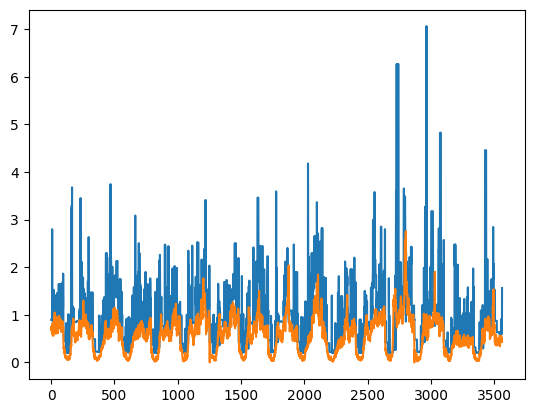

In [21]:
plt.plot(static_cplus[:,0],label='Static + cplus')
plt.plot(output_norm[:,0],label='Real data')

In [9]:
cplus_np[154,0]

0.0972716075686697

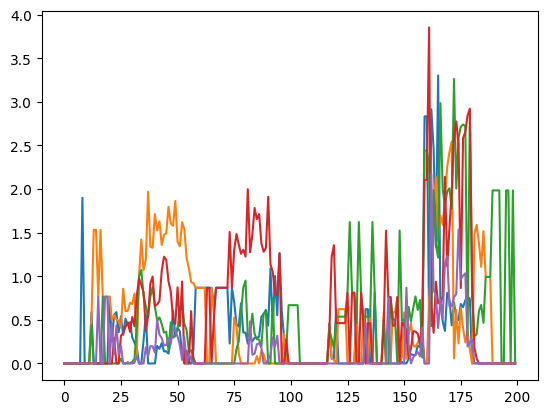

In [10]:
plt.plot(cplus[:200])

In [ ]:
forecasting = mae_norm[t]
ecdf = ECDF(forecasting[service])
static_time = static_norm[t,service]
shared_time = shared_norm[t]
cplus_time = cplus_np[t,service]
output_norm_time = output_norm[t,service]

In [90]:
x = np.sort(forecasting[service])

In [91]:
static_norm.shape

(3561, 5)

In [93]:
x[0]

0.24334116429871697

In [88]:
aaa.iloc[600,:]

0    156
1      4
Name: 600, dtype: int64

In [19]:
x[-1]

0.4009976434749133

In [20]:
static_time

0.3611696717851383

In [18]:
static_time_scaled

array([[0.83554163]])

In [23]:

# if static_time > x[-1]:

In [31]:
x_scaled.reshape(-1).shape

(100,)

In [38]:
static_time_scaled.shape

(1, 1)

In [39]:
static_time_scaled_shaped = static_time_scaled.reshape(-1)

In [44]:
static_time_scaled[0]

array([0.83554163])

In [41]:
static_time_scaled_shaped.reshape(-1).shape

(1,)

In [42]:
static_time_scaled_shaped

array([0.83554163])

In [55]:
x_scaled[x_scaled <= static_time_scaled]

array([0.        , 0.17182501, 0.19519426, 0.21156859, 0.24165886,
       0.24435525, 0.25742623, 0.27105574, 0.2734652 , 0.27768367,
       0.28329283, 0.28486276, 0.3168878 , 0.31915083, 0.32203918,
       0.32310478, 0.34421621, 0.34783495, 0.35683316, 0.37194067,
       0.37249111, 0.37318234, 0.3734298 , 0.39120681, 0.39315502,
       0.39337329, 0.39479939, 0.39750763, 0.39786206, 0.39965242,
       0.40772712])

In [57]:
x_scaled.shape

(100, 1)

In [58]:
y.shape

(100,)

In [6]:
from matplotlib import rc_file
rc_file('/home/sergi_alcala/Matplotlib/mplconf.rc')

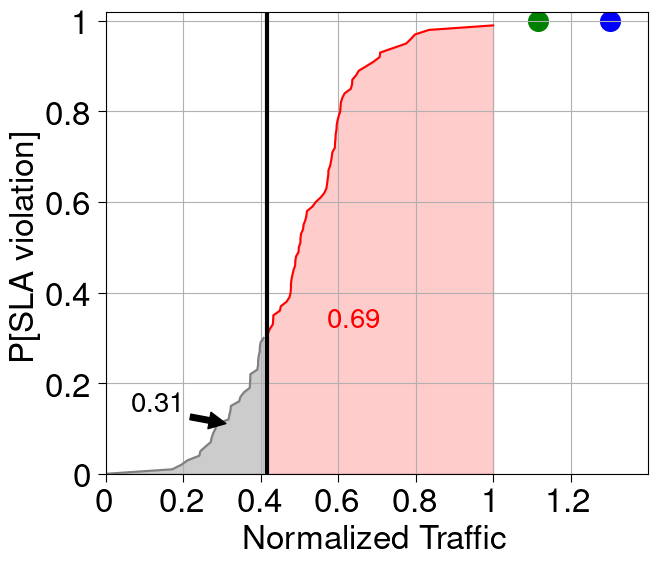

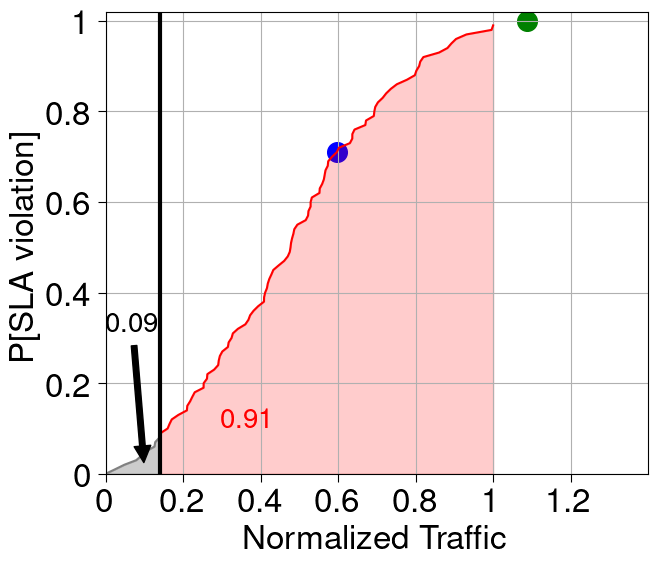

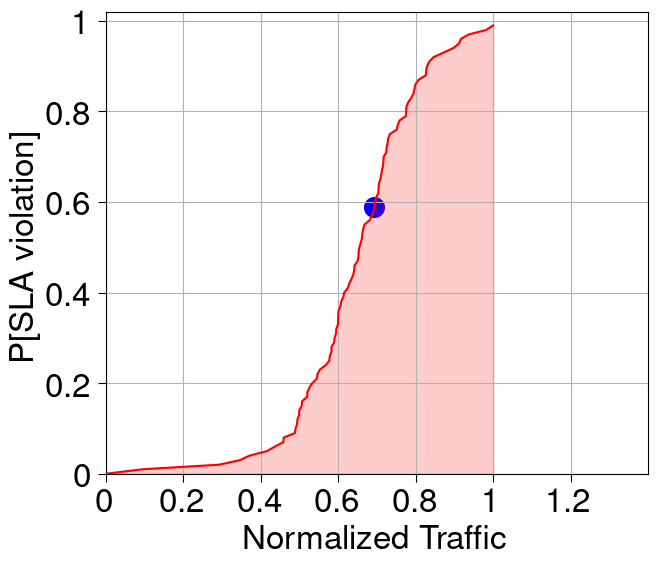

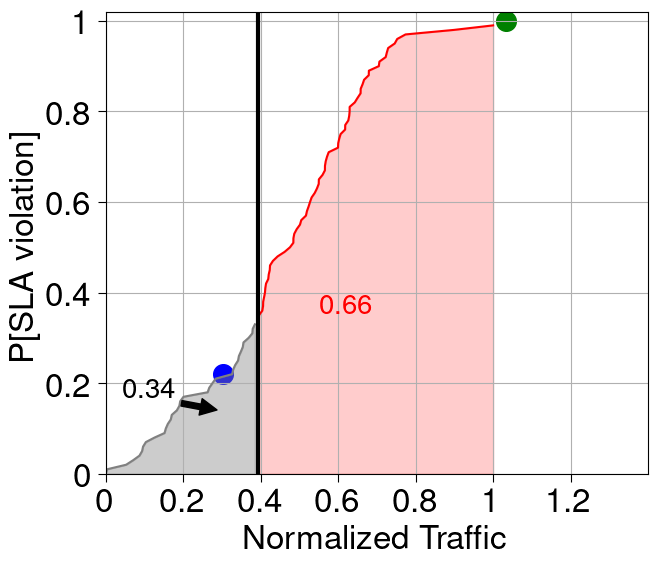

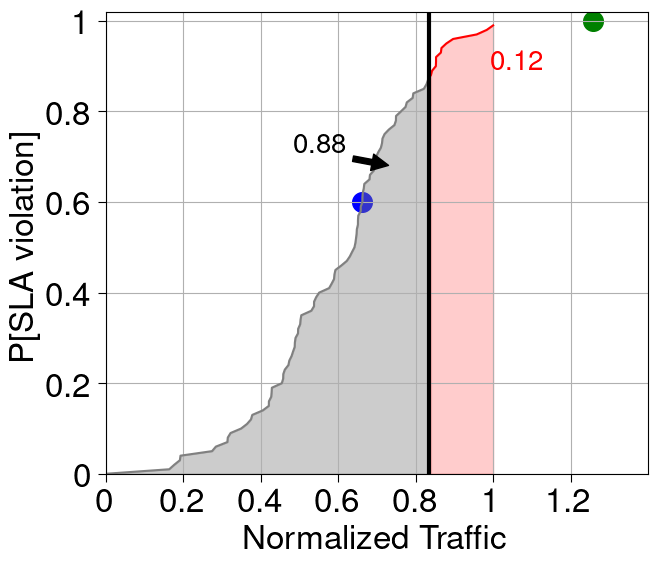

In [7]:

time = 155
#time for all plots == 155
#time for plot of dedicated capacity enough ==2
lower_bound = np.ones(num_services) * 1e-10
upper_bound = np.ones(num_services) * 0.99999
cplus_np = np.array(cplus)
services = [0,1,2,3,4]
# services = [1]
services_names =['Deezer','Twitter','Netflix','DailyMotion','Google']

for service in services:
    for t in [time]:
    # for t in range(time):
        forecasting = mae_norm[t]
        ecdf = ECDF(forecasting[service])
        static_time = static_norm[t,service]
        shared_time = shared_norm[t]
        cplus_time = cplus_np[t,service]
        output_norm_time = output_norm[t,service]

        prob= ecdf(static_time)
        prob_real = ecdf(output_norm_time)
        # if prob != 1:
        # print(f'At time {t} the service {service} needs shared capacity')
        x = np.sort(forecasting[service])
        y = np.arange(len(x))/float(len(x))
        y = y.reshape(-1,1)
        # print(static_time)
        prob_shared = ecdf(static_time + cplus_time)

        ### normalization X axes
        scaler = MinMaxScaler()
        x_scaled = scaler.fit_transform(x.reshape(-1,1))
        static_time_scaled = scaler.transform(static_time.reshape(-1,1))
        shared_time_scaled = scaler.transform(shared_time.reshape(-1,1))
        cplus_time_scaled = scaler.transform(cplus_time.reshape(-1,1))
        output_norm_time_scaled = scaler.transform(output_norm_time.reshape(-1,1))
        static_cplus_scaled = scaler.transform((static_time + cplus_time).reshape(-1,1))

        ############################

        scatter_size = 200

        fig, ax =plt.subplots(figsize=(7,6))
        # ax.plot(x_scaled, y,color='grey',label='ECDF')

            # Plot the line before the change point
        ax.plot(x_scaled[x_scaled <= static_time_scaled], y[x_scaled <= static_time_scaled], color='grey',label=r'$\delta_i(t)$')

        # Plot the line after the change point
        ax.plot(x_scaled[x_scaled > static_time_scaled], y[x_scaled > static_time_scaled], color='red',label=r'$\rho_i(t)$')



        # ax.scatter(static_time, prob)
        ax.scatter(output_norm_time_scaled, prob_real, color='blue',label=r'$\lambda_i (t)$',s=scatter_size)
        # print(f'Prob shared: {prob_shared}')
        ax.scatter(static_cplus_scaled, prob_shared, color='green',label=r'$x_s^i (t)$',s=scatter_size)
        ax.vlines(static_time_scaled, 0, 1.02, color='black', linestyle='solid', label=r'$x_i^d(t)$',linewidth=3)


        x_scaled_shaped = x_scaled.reshape(-1)
        static_time_scaled_shaped = static_time_scaled.reshape(-1)
        y = y.reshape(-1)


        ax.fill_between(x_scaled_shaped, y, where=(x_scaled_shaped > static_time_scaled[0]), color='red', alpha=0.2)
        # ax.annotate(f'{round((1-prob),3)}', xy=(static_time_scaled+0.2, prob), textcoords="offset points", xytext=(8,5), ha='center',fontsize=20,color = 'red')
        # arrowprops=dict(facecolor='red', shrink=0.05),
        #     fontsize=16,fontweight='bold')
        

        ax.fill_between(x_scaled_shaped, y, where=(x_scaled_shaped < static_time_scaled[0]), color='grey', alpha=0.4)

        if time == 155 and service == 1:


            ax.annotate(f'{round(prob,3)}', (0.1, 0.01), textcoords="offset points", xytext=(-8,100), ha='center',
            arrowprops=dict(facecolor='black', shrink=0.05),
                fontsize=20,fontweight='bold')

            ax.annotate(f'{round((1-prob),3)}', xy=(static_time_scaled+0.2, prob), textcoords="offset points", xytext=(8,5), ha='center',fontsize=20,color = 'red')

        elif time == 2 and service == 0:
            ax.annotate(f'{round(prob,3)}', (0.5, 0.7), textcoords="offset points", xytext=(-50,10), ha='center',
            arrowprops=dict(facecolor='black', shrink=0.05),
                fontsize=20,fontweight='bold')


        else:


            ax.annotate(f'{round(prob,3)}', (static_time_scaled-0.1, prob-0.2), textcoords="offset points", xytext=(-50,10), ha='center',
            arrowprops=dict(facecolor='black', shrink=0.05),
                fontsize=20,fontweight='bold')

            ax.annotate(f'{round((1-prob),3)}', xy=(static_time_scaled+0.2, prob), textcoords="offset points", xytext=(8,5), ha='center',fontsize=20,color = 'red')

        
        ax.set_ylim(0,1.02)
        ax.set_xlim(0,1.4)
        # ax.set_title(f'Service {services_names[service]} at time {t}')
        ax.set_ylabel('P[SLA violation]')
        ax.set_xlabel('Normalized Traffic')
        ax.set_xticks(np.arange(0,1.4,0.2))
        ax.set_xticklabels([0,0.2,0.4,0.6,0.8,1,1.2])

        ax.set_yticks(np.arange(0,1.2,0.2))
        ax.set_yticklabels([0,0.2,0.4,0.6,0.8,1])


        # ax.annotate(f'Static capacity: {round(static_time,3)}', (static_time, prob), textcoords="offset points", xytext=(-50,10), ha='center')
        # ax.annotate(f'Shared capacity: {round((static_time + cplus_time),3)}', (static_time + cplus_time, prob_shared), textcoords="offset points", xytext=(0,5), ha='center')
        ax.grid()
        # ax.legend(bbox_to_anchor=(0.9, 1.5), loc='upper left',ncol = 4)
        # legend = plt.legend(loc='upper left',ncol = 5)

        ############# Create a separate figure for the legend################
        # fig_legend = plt.figure(figsize=(20, 2))
        # ax_legend = fig_legend.add_subplot(111)
        # ax_legend.axis('off')
        # legend = ax_legend.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False,ncol= 5,fontsize=30)

        # # Save the legend as a standalone file
        # fig_legend.savefig('../FIGS/ECDF_bobyqa_LEGEND.pdf', bbox_inches='tight', dpi=300)
                


        if time == 155 and service == 0:
        
            plt.savefig(f'../FIGS/ECDF_bobyqa_service_{service}_SLA.pdf',bbox_inches='tight')

        elif time == 155 and service == 1:

            plt.savefig(f'../FIGS/ECDF_bobyqa_service_{service}_needed_shared.pdf',bbox_inches='tight')

       

        elif time == 155 and service == 3:
            plt.savefig(f'../FIGS/ECDF_bobyqa_service_{service}_cplus.pdf',bbox_inches='tight')

        elif time == 2 and service == 0:
            plt.savefig(f'../FIGS/ECDF_bobyqa_service_{service}_dedicated.pdf',bbox_inches='tight')
        
        break

    

Prob shared: 1.0
Prob shared: 1.0
Prob shared: 1.0
Prob shared: 1.0
Prob shared: 1.0


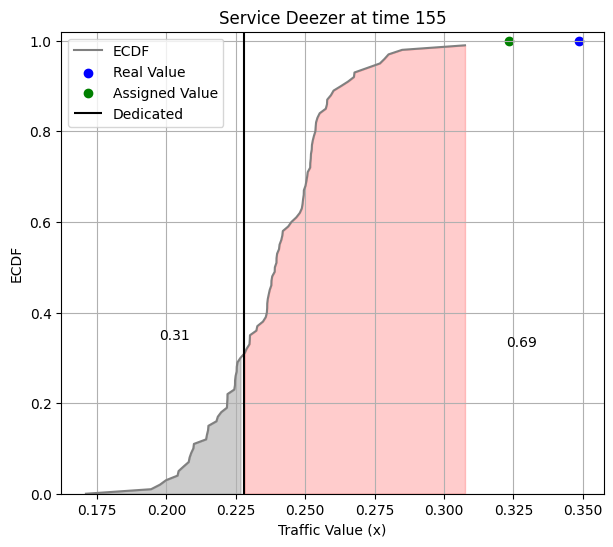

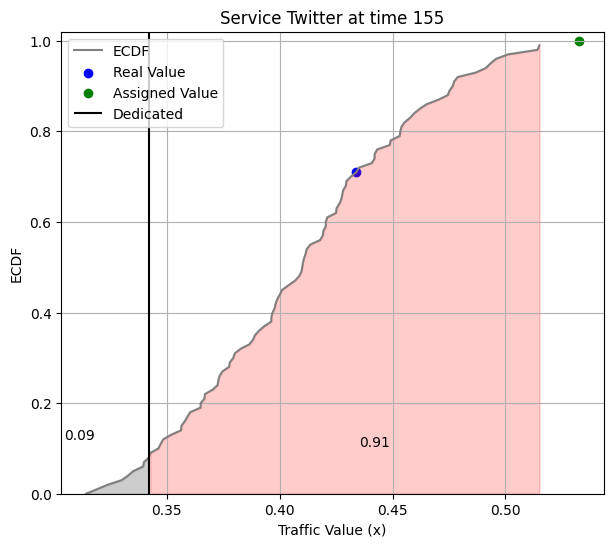

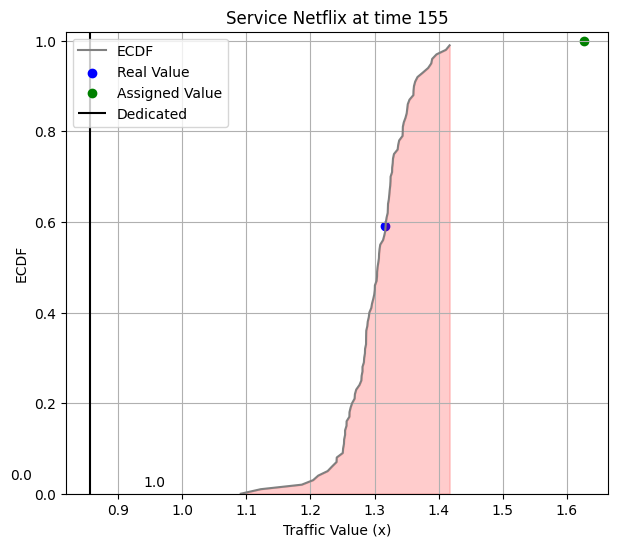

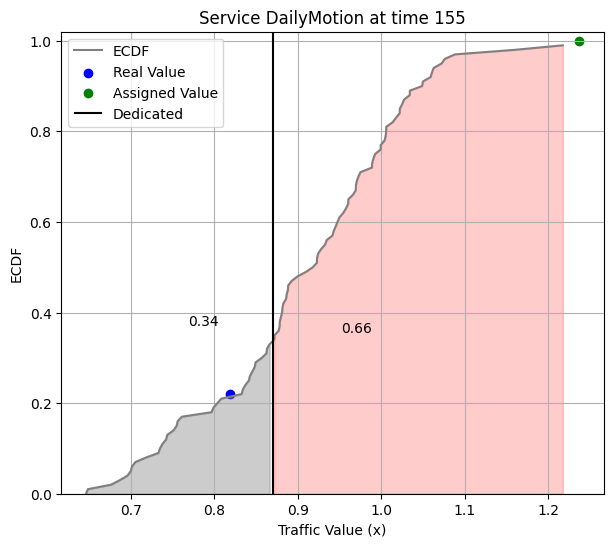

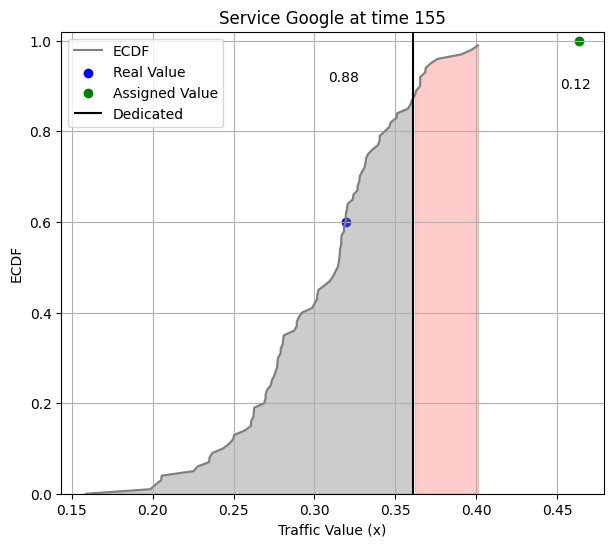

In [12]:
time = 155
#time for all plots == 155
#time for plot of dedicated capacity enough ==2
lower_bound = np.ones(num_services) * 1e-10
upper_bound = np.ones(num_services) * 0.99999
cplus_np = np.array(cplus)
services = [0,1,2,3,4]
# services = [0]
services_names =['Deezer','Twitter','Netflix','DailyMotion','Google']

for service in services:
    for t in [time]:
    # for t in range(time):
        forecasting = mae_norm[t]
        ecdf = ECDF(forecasting[service])
        static_time = static_norm[t,service]
        shared_time = shared_norm[t]
        cplus_time = cplus_np[t,service]
        output_norm_time = output_norm[t,service]

        prob= ecdf(static_time)
        prob_real = ecdf(output_norm_time)
        # if prob != 1:
        # print(f'At time {t} the service {service} needs shared capacity')
        x = np.sort(forecasting[service])
        y = np.arange(len(x))/float(len(x))
        # print(static_time)
        prob_shared = ecdf(static_time + cplus_time)

        # if static_time > x[-1]:

        fig, ax =plt.subplots(figsize=(7,6))
        ax.plot(x, y,color='grey',label='ECDF')
        # ax.scatter(static_time, prob)
        ax.scatter(output_norm_time, prob_real, color='blue',label='Real Value')
        print(f'Prob shared: {prob_shared}')
        ax.scatter(static_time + cplus_time, prob_shared, color='green',label='Assigned Value')
        ax.vlines(static_time, 0, 1.02, color='black', linestyle='solid', label='Dedicated')

        ax.fill_between(x, y, where=(x > static_time), color='red', alpha=0.2)
        ax.annotate(f'{round(prob,3)}', (static_time, prob), textcoords="offset points", xytext=(-50,10), ha='center')
        

        ax.fill_between(x, y, where=(x < static_time), color='grey', alpha=0.4)
        ax.annotate(f'{round((1-prob),3)}', (static_time+0.1, prob), textcoords="offset points", xytext=(0,5), ha='center')

        
        ax.set_ylim(0,1.02)
        ax.set_title(f'Service {services_names[service]} at time {t}')
        ax.set_ylabel('ECDF')
        ax.set_xlabel('Traffic Value (x)')
        # ax.annotate(f'Static capacity: {round(static_time,3)}', (static_time, prob), textcoords="offset points", xytext=(-50,10), ha='center')
        # ax.annotate(f'Shared capacity: {round((static_time + cplus_time),3)}', (static_time + cplus_time, prob_shared), textcoords="offset points", xytext=(0,5), ha='center')
        ax.grid()
        ax.legend()


        break

    

In [43]:
p_0 = np.ones(1) * 0.5 

In [45]:

                
obj_noise_test = True
# Golden search for setting p4
test = scipy.optimize.minimize_scalar(fun, bounds=(1e-10, 0.99999), method='bounded',
                                    args=(forecasting[service], static_norm[time, service],
                                            shared_norm[time], phi, alpha, lower_bound, upper_bound,obj_noise_test))

p4 = test.x # p4 obtained using golden search
p_0 = np.ones(0) * 0.5 # initial values of p from 0 to 3
# Finding the best initial values of p from 0 to 3 keeping p4 fixed. BOBYQA for p from 0 to 3.


# prova = pybobyqa.solve(cost_func_evaluation_p_fix_p4, p_0, bounds=(lower_bound[:len(idx_app)-1],
#                                                                 upper_bound[:len(idx_app)-1]),
#                     args=(forecasting[service], static_norm[time, service],
#                             shared_norm[time], p4, phi, alpha), objfun_has_noise=True)
                

IndexError: index 3561 is out of bounds for axis 0 with size 3561

In [ ]:

def cost_func_evaluation_p_fix_p4(p, forecasting, static, shared_available, p4,
                                  phi, alpha):
    ''' Evaluate the cost of the allocation given cplus selected.'''
    # cost_shared = phi
    cost_sla = alpha
    total_cost = 0
    cplus, cplus_4 = return_cplus_fix_p4(p, shared_available, p4)
    for i in range(forecasting.shape[0]):  # shape[0] = num services
        # total_cost += cplus[i] * phi
        ecdf = ECDF(forecasting[i])
        total_cost += (1-ecdf(static[i] + cplus[i])) * cost_sla
    return total_cost

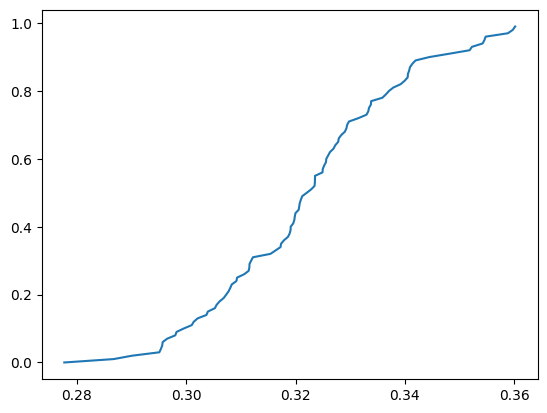

In [28]:
x = np.sort(forecasting[0])
y = np.arange(len(x))/float(len(x))
plt.plot(x, y)

In [29]:
static_100[0]

0.4438409095900323

In [22]:
ecdf = ECDF(forecasting[0])

In [27]:
ecdf(static_100[0])

1.0

In [20]:
forecasting.shape

(5, 100)